# Data Loading

In [1]:
# Import the libraries required
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt

In [2]:
# Load the Topo Chico dataset
df = pd.read_csv("datasets/topo chico_from_dump.csv")
df

,code,product_name,brands,categories_tags,countries_tags,packaging_tags,stores,purchase_places,nutriscore_grade,nova_group,ecoscore_grade,ingredients_text,nutriments.sugars_100g,nutriments.energy-kcal_100g
0,0021136010374,MINERAL WATER CARBONATED,Topo Chico,undefined,united-states,"bottle-or-vial, bottle, glass-bottle",NaN,NaN,a,NaN,NaN,CARBONATED MINERAL WATER BOTTLED ONLY AT SOURCE.,NaN,NaN
1,0021136010480,Agua Mineral,Cia. Topo Chico S.A.,"beverages-and-beverages-preparations, beverage...","mexico, united-states",NaN,NaN,NaN,a,4.0,NaN,MINERAL WATER AND CARBON DIOXIDE.,NaN,NaN
2,0021136010626,"Topo Chico, Sparkling Carbonatada Agua Mineral...",Cia. Topo Chico S.A.,"beverages, waters",united-states,NaN,NaN,NaN,unknown,4.0,NaN,"Mineral water, carbon dioxide.",NaN,NaN
3,0021136011500,Soda,Cia. Topo Chico S.A.,"beverages, carbonated-drinks, sodas",united-states,NaN,NaN,NaN,e,4.0,not-applicable,"Carbonated water, cane sugar, artificial and n...",10.99,42.0
4,0021136011579,"Topo Chico, Carbonated Beverage, Apple",Cia. Topo Chico S.A.,"beverages, carbonated-drinks, sodas",united-states,NaN,NaN,NaN,e,4.0,not-applicable,"Carbonated water, cane sugar, citric acid, car...",12.24,49.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76,0993350000724,Topo chico,NaN,NaN,mexico,NaN,NaN,NaN,unknown,NaN,NaN,NaN,NaN,NaN
77,0810078782193,Margarita Flavored Alcohol Beverage,Topo Chico,NaN,united-states,NaN,NaN,NaN,unknown,NaN,NaN,NaN,NaN,NaN
78,0721136000480,Topo chico 1.5L,NaN,NaN,mexico,NaN,NaN,NaN,unknown,NaN,NaN,NaN,NaN,NaN
79,01219258,Raspberry with Lemon Flavored Sparkling Water,Topo Chico Sabores,NaN,united-states,NaN,NaN,NaN,unknown,NaN,NaN,NaN,NaN,NaN


# Data Cleaning

In [3]:
# Inspect the data types of all columns to identify any required conversions.
df.dtypes

code                            object
product_name                    object
brands                          object
categories_tags                 object
countries_tags                  object
packaging_tags                  object
stores                          object
purchase_places                 object
nutriscore_grade                object
nova_group                     float64
ecoscore_grade                  object
ingredients_text                object
nutriments.sugars_100g         float64
nutriments.energy-kcal_100g    float64
dtype: object

In [4]:
# Examine the product code values before converting the column to a numeric type.
df.code.unique()

array(['0021136010374', '0021136010480', '0021136010626', '0021136011500',
       '0021136011579', '0021136013504', '0021136013573', '0021136014501',
       '0021136015508', '0021136016185', '0021136019506', '0021136019575',
       '0021136020373', '0021136050462', '0021136110180', '0021136120448',
       '0021136414370', '0021136616507', '0021136010541', '0021136010534',
       '5449000294722', '5449000294746', '0021136180619', '5449000294708',
       '0021136180657', '0021136010350', '0021136180794', '0021136016444',
       '5000112650150', '0021136180800', '5449000300904', '0021136180817',
       '0021136180558', '0021136180954', '0021136180701', '0021136180664',
       '0810078780014', '2004361007713', '91055901860836515341',
       '0021136180596', '0021136180626', '0021136010121', '0810078780045',
       '0810078780342', '0021136180947', '0810078780021', '0021136181166',
       '5000112650167', '0021136110449', '0810078780564', '0810078781035',
       '7894900335040', '7894900335

In [5]:
# Convert the product code column to float format first cauz values are big.
df=df.astype({"code": "float64"})

In [6]:
# Convert the product code column to integer format.
df=df.astype({"code": "int64"})

In [7]:
# Review the unique brand names to identify inconsistent spellings.
df.brands.unique()

array(['Topo Chico', 'Cia. Topo Chico  S.A.', nan, 'Coca-Cola Company',
       'Topo chico', 'topo chico', 'Too Chico', 'TOPO CHICO',
       'Topo Chico Sabores', 'Topo Chico Hard'], dtype=object)

In [8]:
# Standardize brand names by correcting inconsistent spellings and capitalization.
# This ensures all variations of the same brand are grouped together.
df.brands = df.brands.replace({
    "Topo chico": "Topo Chico",
    "topo chico": "Topo Chico",
    "TOPO CHICO": "Topo Chico",
    "Too Chico": "Topo Chico"
}, regex=True)

In [9]:
# Replace missing brand values with 'Unknown' to avoid null values.
df.brands = df.brands.fillna("unknown")
df.brands.isnull().sum()

np.int64(0)

In [10]:
# Replace missing values in selected categorical columns with 'Unknown'.
cols = [
    "categories_tags",
    "countries_tags",
    "packaging_tags",
    "stores",
    "purchase_places",
    "ecoscore_grade",
    "ingredients_text"
]

df[cols] = df[cols].fillna("Unknown")

# Data Preparation

In [11]:
# Create a cleaned copy of the dataset.
# All subsequent preprocessing steps are performed on this copy to preserve the original data.
df_clean = df.copy()

In [12]:
# Split multiple country tags into individual rows and standardize
# the text by trimming spaces and converting to lowercase.
country_df = df_clean.copy()
country_df["countries_tags"] = country_df["countries_tags"].str.split(",")
country_df = country_df.explode("countries_tags")
country_df["countries_tags"] = country_df["countries_tags"].str.strip().str.lower()


In [13]:
# Split multiple packaging tags into separate rows and standardize
# the values for accurate packaging analysis.
pack_df = df_clean.copy()
pack_df["packaging_tags"] = pack_df["packaging_tags"].str.split(",")
pack_df = pack_df.explode("packaging_tags")
pack_df["packaging_tags"] = pack_df["packaging_tags"].str.strip().str.lower()

In [14]:
# Split multiple category tags into separate rows and standardize
# the text for consistent category analysis.
cat_df = df_clean.copy()
cat_df["categories_tags"] = cat_df["categories_tags"].str.split(",")
cat_df = cat_df.explode("categories_tags")
cat_df["categories_tags"] = cat_df["categories_tags"].str.strip().str.lower()

In [15]:
# Split multiple store names into individual rows and standardize
# the values for store-level analysis.
store_df = df_clean.copy()
store_df["stores"] = store_df["stores"].str.split(",")
store_df = store_df.explode("stores")
store_df["stores"] = store_df["stores"].str.strip().str.lower()

In [16]:
# Display the frequency of each brand.
df.brands.value_counts()

brands
Topo Chico               44
unknown                  16
Cia. Topo Chico  S.A.    15
Topo Chico Sabores        4
Coca-Cola Company         1
Topo Chico Hard           1
Name: count, dtype: int64

In [17]:
# Display the number of products available in each country.
country_df.value_counts("countries_tags")

countries_tags
united-states    60
spain             6
mexico            5
brazil            3
germany           2
luxembourg        2
france            1
italy             1
japan             1
saudi-arabia      1
unknown           1
Name: count, dtype: int64

In [18]:
# Display the frequency of each packaging type.
pack_df.value_counts("packaging_tags")

packaging_tags
unknown                          72
bottle                            5
aluminium                         3
metal                             3
recyclable-metals                 3
bottle-or-vial                    1
de:al                             1
glass-bottle                      1
pet-desechable-con-taparrosca     1
Name: count, dtype: int64

In [19]:
# Display the frequency of each product category.
cat_df.value_counts("categories_tags")

categories_tags
beverages                               44
unknown                                 34
beverages-and-beverages-preparations    22
waters                                  20
carbonated-drinks                       15
alcoholic-beverages                     13
carbonated-waters                        8
mineral-waters                           7
spring-waters                            7
sodas                                    7
hard-seltzer                             4
undefined                                3
carbonated-mineral-waters                2
vodka-based-alcoholic-beverages          2
premixed-alcoholic-beverages             2
hard-seltzers                            2
de:selt                                  1
de:wein                                  1
de:ready-to-drink                        1
de:premixgetränk                         1
de:hard-seltzer                          1
de:alkopop                               1
de:alkoholhaltiges-mischgetränk       

In [20]:
# Display the frequency of products available across stores.
store_df.value_counts("stores")

stores
unknown         77
carrefour.fr     2
abarrotes        1
chedraui         1
hagebaumarkt     1
la plancha       1
méxico           1
sam's            1
soriana          1
walmart          1
Name: count, dtype: int64

In [21]:
# Calculate the total number of unique brands.
print("Total Brands :", df["brands"].nunique())

Total Brands : 6


In [22]:
# Calculate the total number of unique categories.
print("Total Categories :", cat_df["categories_tags"].nunique())

Total Categories : 25


In [23]:
# Calculate the total number of unique countries.
print("Total Countries :", country_df["countries_tags"].nunique())

Total Countries : 11


In [24]:
# Calculate the total number of unique packaging types.
print("Total Packaging Types :", pack_df["packaging_tags"].nunique())

Total Packaging Types : 9


In [25]:
# Calculate the total number of unique stores.
print("Total Stores :", store_df["stores"].nunique())

Total Stores : 10


# Dataset Summary

In [26]:
# Convert all non-numeric columns to object type to ensure
df[df.select_dtypes(exclude='number').columns] = df.select_dtypes(exclude='number').astype(object)

In [27]:
# Create a summary table showing the number of unique values,
# missing values, and data type for each column.
# This provides an overview of the dataset after preprocessing.
summary = pd.DataFrame({
    "Unique Values": df.nunique(),
    "Missing Values": df.isnull().sum(),
    "Data Type": df.dtypes
})

summary

,Unique Values,Missing Values,Data Type
code,81,0,int64
product_name,65,0,object
brands,6,0,object
categories_tags,18,0,object
countries_tags,13,0,object
packaging_tags,6,0,object
stores,4,0,object
purchase_places,2,0,object
nutriscore_grade,6,0,object
nova_group,2,43,float64


# First lets analyze one column at a time 

Brands

In [28]:
# Check brand statistics and frequency distribution.
print(df["brands"].describe())

df["brands"].value_counts()

count             81
unique             6
top       Topo Chico
freq              44
Name: brands, dtype: object


brands
Topo Chico               44
unknown                  16
Cia. Topo Chico  S.A.    15
Topo Chico Sabores        4
Coca-Cola Company         1
Topo Chico Hard           1
Name: count, dtype: int64

### Insight: Brand distribution

**Background:** Brand information shows how the 81 products are distributed across recorded brand names. Missing brand values were standardized as `unknown`, and the dataset contains several Topo Chico naming variants.

**Finding:** `Topo Chico` is the most common recorded brand with **44 products (54.3%)**. `unknown` accounts for **16 products (19.8%)**, while `Cia. Topo Chico S.A.` accounts for **15 products (18.5%)**. `Topo Chico Sabores` has 4 products, while `Coca-Cola Company` and `Topo Chico Hard` have 1 product each.

**Interpretation:** The dataset is strongly concentrated around the Topo Chico brand family. However, the presence of 16 unknown brand records means the exact brand distribution is incomplete.

**Why this matters:** The strongest conclusion is that the dataset is dominated by Topo Chico-labelled products. Brand-level comparisons should therefore be treated as dataset-specific rather than as overall market-share estimates.


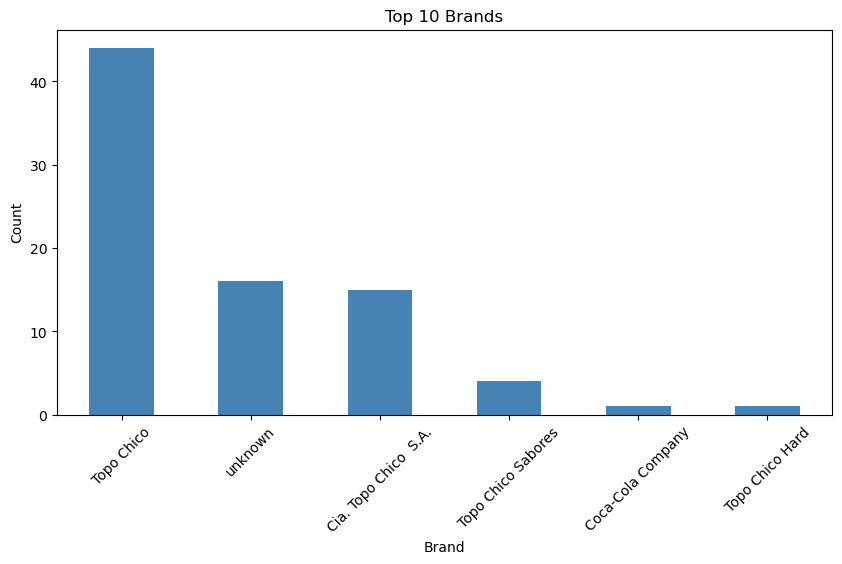

In [29]:
# Visualize the most common brands.
plt.figure(figsize=(10,5))

df["brands"].value_counts().head(10).plot(
    kind="bar",
    color="steelblue"
)

plt.title("Top 10 Brands")
plt.xlabel("Brand")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

Categories

In [30]:
# Check the most common product categories.
cat_df["categories_tags"].value_counts().head(15)

categories_tags
beverages                               44
unknown                                 34
beverages-and-beverages-preparations    22
waters                                  20
carbonated-drinks                       15
alcoholic-beverages                     13
carbonated-waters                        8
spring-waters                            7
mineral-waters                           7
sodas                                    7
hard-seltzer                             4
undefined                                3
premixed-alcoholic-beverages             2
hard-seltzers                            2
carbonated-mineral-waters                2
Name: count, dtype: int64

### Insight: Product category distribution

**Background:** Category tags describe the type of beverage represented by each product. Because one product may have multiple category tags, the category dataframe is exploded and the counts represent **tag occurrences**, not necessarily unique products.

**Finding:** `beverages` is the most frequent category with **44 occurrences**, followed by `beverages-and-beverages-preparations` (22), `waters` (20), and `carbonated-drinks` (15). Alcohol-related categories are also present, including `alcoholic-beverages` (13), while hard-seltzer categories occur less frequently. There are also **34 unknown category occurrences**.

**Interpretation:** The portfolio is mainly beverage-oriented, with strong representation of water and carbonated-drink categories. The presence of alcoholic-beverage and hard-seltzer tags shows that the dataset extends beyond conventional mineral or sparkling water.

**Why this matters:** Category analysis helps identify the product mix, but tag counts should not be interpreted as unique-product counts because products can have multiple category labels.


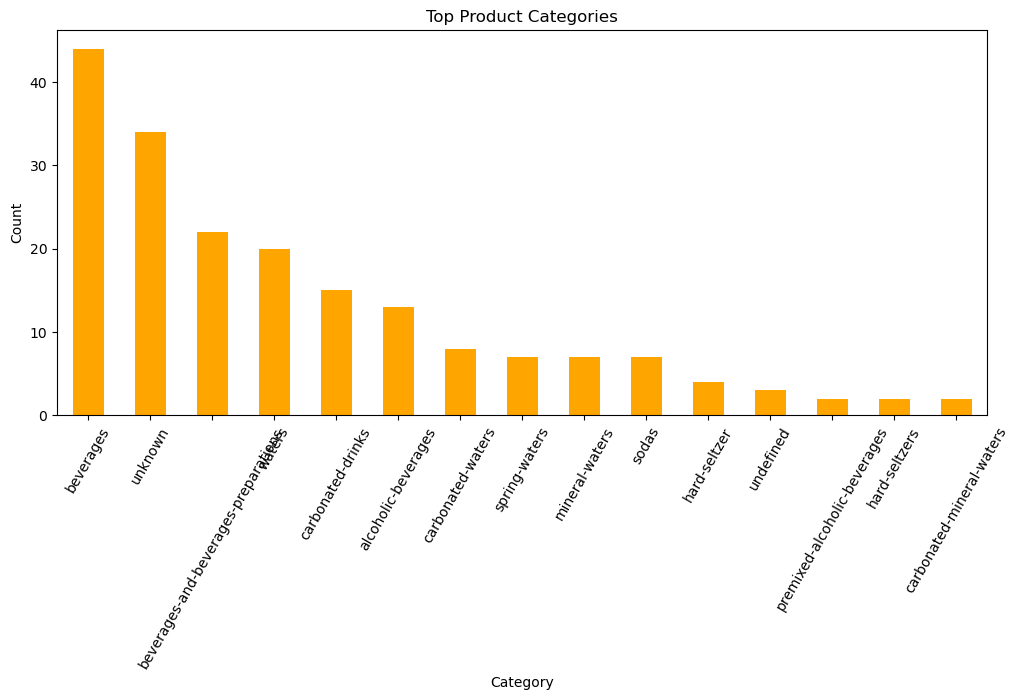

In [31]:
# Visualize the most common product categories.
plt.figure(figsize=(12,5))

cat_df["categories_tags"].value_counts().head(15).plot(
    kind="bar",
    color="orange"
)

plt.title("Top Product Categories")
plt.xlabel("Category")
plt.ylabel("Count")

plt.xticks(rotation=60)

plt.show()

Countries

In [32]:
# Check the countries with the highest number of products.
country_df["countries_tags"].value_counts().head(15)

countries_tags
united-states    60
spain             6
mexico            5
brazil            3
luxembourg        2
germany           2
unknown           1
france            1
italy             1
saudi-arabia      1
japan             1
Name: count, dtype: int64

### Insight: Geographic distribution

**Background:** Country tags indicate the countries associated with products. Products with multiple country tags are split into separate country rows, so country counts describe the tagged portfolio rather than mutually exclusive markets.

**Finding:** The United States has **60 unique products**, followed by Spain (6), Mexico (5), Brazil (3), Germany and Luxembourg (2 each), and several countries with only 1 product.

**Interpretation:** The dataset is **heavily U.S.-focused**. The United States represents about **74.1% of the 81 unique products**, making it the main source of evidence for country-level analysis.

**Why this matters:** Comparisons involving countries with one or two products should be treated as descriptive only. The dataset is not geographically balanced enough to support broad country-level market conclusions.


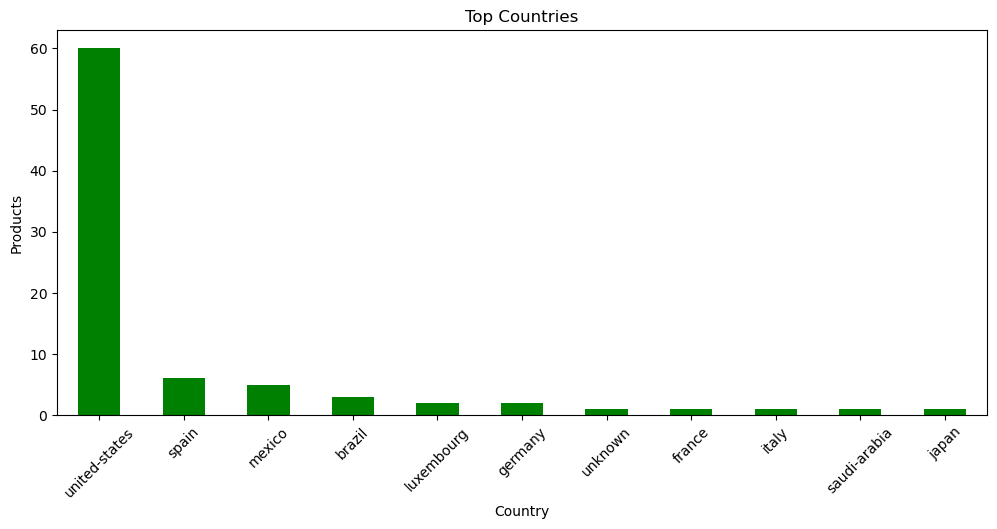

In [33]:
# Visualize product counts across countries.
plt.figure(figsize=(12,5))

country_df["countries_tags"].value_counts().plot(
    kind="bar",
    color="green"
)

plt.title("Top Countries")
plt.xlabel("Country")
plt.ylabel("Products")

plt.xticks(rotation=45)

plt.show()

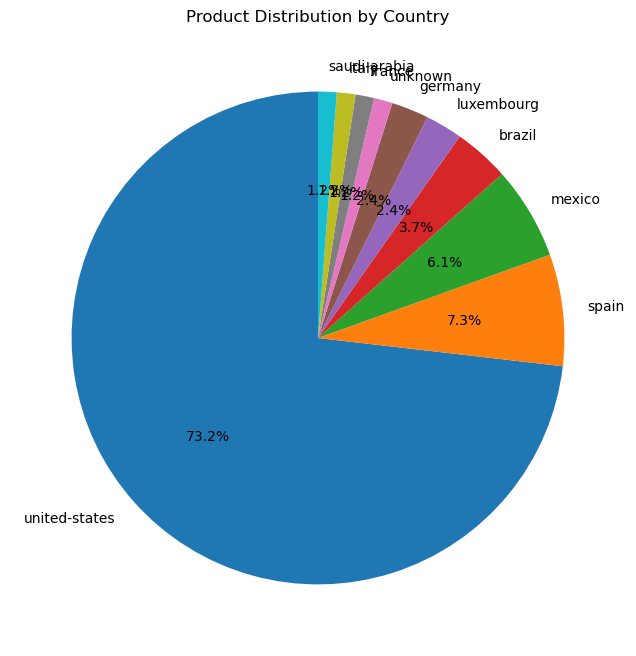

In [34]:
# Visualize the top 10 countries as a percentage distribution.
top10 = country_df["countries_tags"].value_counts().head(10)

plt.figure(figsize=(8,8))

plt.pie(
    top10,
    labels=top10.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Product Distribution by Country")

plt.show()

Packaging

In [35]:
# Check the most common packaging types.
pack_df["packaging_tags"].value_counts().head(15)

packaging_tags
unknown                          72
bottle                            5
metal                             3
recyclable-metals                 3
aluminium                         3
bottle-or-vial                    1
glass-bottle                      1
pet-desechable-con-taparrosca     1
de:al                             1
Name: count, dtype: int64

### Insight: Packaging distribution

**Background:** Packaging tags describe the recorded packaging format of products. Missing packaging information was standardized as `unknown`.

**Finding:** **72 of 81 records (88.9%) are `unknown`**. Among the identified packaging types, `bottle` appears 5 times, while `metal`, `recyclable-metals`, and `aluminium` each appear 3 times. Glass bottle and other specific packaging descriptions occur only once.

**Interpretation:** Bottles are the most common identifiable packaging format, but the very high unknown share makes the overall packaging mix unreliable.

**Why this matters:** The current dataset is not sufficient for a strong packaging-sustainability or material comparison. Better packaging metadata would be needed before estimating plastic, glass, or metal shares.


Stores

In [36]:
# Check the stores with the highest product counts.
store_df["stores"].value_counts().head(15)

stores
unknown         77
carrefour.fr     2
la plancha       1
méxico           1
soriana          1
abarrotes        1
chedraui         1
walmart          1
sam's            1
hagebaumarkt     1
Name: count, dtype: int64

### Insight: Store distribution

**Background:** Store tags indicate retailers or stores associated with the products. Missing store information was recorded as `unknown`.

**Finding:** **77 of 81 records (95.1%) are marked `unknown`**. `carrefour.fr` appears twice, while the remaining named stores appear only once each.

**Interpretation:** Retailer coverage is extremely limited. The available store names do not provide enough evidence to identify a meaningful distribution or retail preference.

**Why this matters:** The main analytical finding is the **lack of retailer metadata**, rather than a particular store being dominant. Store-level conclusions should therefore be avoided.


Purchase Places

In [37]:
# Check the most common product purchase locations.
df["purchase_places"].value_counts().head(15)

purchase_places
Unknown        80
Deutschland     1
Name: count, dtype: int64

### Insight: Purchase-place distribution

**Background:** Purchase place records where the product was purchased or associated with a purchase location.

**Finding:** **80 of 81 records (98.8%) are `Unknown`**, while only one record is associated with `Deutschland`.

**Interpretation:** The purchase-place field is almost completely missing. The single Germany-related entry is insufficient to establish any purchasing pattern.

**Why this matters:** Purchase-place analysis is currently not actionable. Additional data collection would be required before making geographic purchasing or consumer-location conclusions.


Eco Score

In [38]:
# Check the distribution of EcoScore grades.
df["ecoscore_grade"].value_counts()

ecoscore_grade
Unknown           57
unknown           16
not-applicable     8
Name: count, dtype: int64

### Insight: EcoScore distribution

**Background:** EcoScore is intended to represent environmental impact. The dataset contains both `Unknown` and `unknown`, which are effectively missing-information categories, plus `not-applicable`.

**Finding:** **73 of 81 records (90.1%) are effectively unknown**, while 8 records (9.9%) are `not-applicable`. No usable graded EcoScore categories are present.

**Interpretation:** The dataset does not provide enough EcoScore information to compare environmental performance across products, countries, or brands.

**Why this matters:** The correct conclusion is a **major EcoScore data-availability gap**, not that the products have poor environmental performance.


In [39]:
# Create a separate dataframe for country-level analysis.
country_df = df.copy()

# Split products containing multiple countries.
country_df["countries_tags"] = (
    country_df["countries_tags"]
    .fillna("")
    .str.split(",")
)

# Create one row for each country.
country_df = country_df.explode("countries_tags")

# Standardize country names.
country_df["countries_tags"] = (
    country_df["countries_tags"]
    .str.strip()
    .str.lower()
)

# Remove rows without a country value.
country_df = country_df[
    country_df["countries_tags"] != ""
]

country_df.head()

,code,product_name,brands,categories_tags,countries_tags,packaging_tags,stores,purchase_places,nutriscore_grade,nova_group,ecoscore_grade,ingredients_text,nutriments.sugars_100g,nutriments.energy-kcal_100g
0,21136010374,MINERAL WATER CARBONATED,Topo Chico,undefined,united-states,"bottle-or-vial, bottle, glass-bottle",Unknown,Unknown,a,NaN,Unknown,CARBONATED MINERAL WATER BOTTLED ONLY AT SOURCE.,NaN,NaN
1,21136010480,Agua Mineral,Cia. Topo Chico S.A.,"beverages-and-beverages-preparations, beverage...",mexico,Unknown,Unknown,Unknown,a,4.0,Unknown,MINERAL WATER AND CARBON DIOXIDE.,NaN,NaN
1,21136010480,Agua Mineral,Cia. Topo Chico S.A.,"beverages-and-beverages-preparations, beverage...",united-states,Unknown,Unknown,Unknown,a,4.0,Unknown,MINERAL WATER AND CARBON DIOXIDE.,NaN,NaN
2,21136010626,"Topo Chico, Sparkling Carbonatada Agua Mineral...",Cia. Topo Chico S.A.,"beverages, waters",united-states,Unknown,Unknown,Unknown,unknown,4.0,Unknown,"Mineral water, carbon dioxide.",NaN,NaN
3,21136011500,Soda,Cia. Topo Chico S.A.,"beverages, carbonated-drinks, sodas",united-states,Unknown,Unknown,Unknown,e,4.0,not-applicable,"Carbonated water, cane sugar, artificial and n...",10.99,42.0


Country-wise product count

In [40]:
# Calculate the number of unique products for each country.
country_product_count = (
    country_df.groupby("countries_tags")["code"]
    .nunique()
    .sort_values(ascending=False)
)

country_product_count.head(20)

countries_tags
united-states    60
spain             6
mexico            5
brazil            3
germany           2
luxembourg        2
france            1
italy             1
japan             1
saudi-arabia      1
unknown           1
Name: code, dtype: int64

### Insight: Country-wise product count

**Background:** Country analysis counts unique product codes within each country after country tags are separated. A product can therefore contribute to more than one country if multiple country tags are present.

**Finding:** The United States has **60 unique products**, Spain 6, Mexico 5, Brazil 3, Germany and Luxembourg 2 each, and the remaining countries 1 each.

**Interpretation:** The product portfolio is strongly concentrated in the United States. The U.S. has roughly ten times the products of Spain and twelve times those of Mexico.

**Why this matters:** The U.S. provides the most reliable country-level evidence in this dataset. Small-country results should be treated as indicative rather than representative.


Country-wise average calories & sugar

In [41]:
# Calculate product count, average calories, and average sugar by country.
country_nutrition = (
    country_df.groupby("countries_tags")
    .agg(
        Products=("code", "nunique"),
        Avg_Calories=("nutriments.energy-kcal_100g", "mean"),
        Avg_Sugar=("nutriments.sugars_100g", "mean")
    )
    .reset_index()
)

country_nutrition = country_nutrition.sort_values(
    "Products",
    ascending=False
)

country_nutrition.head(20)

,countries_tags,Products,Avg_Calories,Avg_Sugar
9,united-states,60,20.301478,3.398282
8,spain,6,NaN,NaN
6,mexico,5,NaN,NaN
0,brazil,3,NaN,NaN
2,germany,2,NaN,NaN
5,luxembourg,2,29.500000,3.400000
1,france,1,NaN,NaN
3,italy,1,NaN,NaN
4,japan,1,5.000000,NaN
7,saudi-arabia,1,27.500000,0.423000


### Insight: Average calories and sugar by country

**Background:** Average calories and sugar are calculated per 100g using only available nutrient values. Missing values are excluded from the mean and are not treated as zero.

**Finding:** The United States averages **20.30 kcal/100g** and **3.40 g sugar/100g** among available values. Luxembourg has **29.50 kcal/100g** and **3.40 g/100g**, Saudi Arabia has **27.50 kcal/100g** and **0.423 g/100g**, and Japan has **5.00 kcal/100g**. Several countries have no usable nutrient values.

**Interpretation:** Luxembourg has the highest reported calorie average, but it is based on only two products. The U.S. result is more informative because of its much larger product count, although nutrient coverage is still incomplete.

**Why this matters:** Country-level nutrient averages should always be considered together with **sample size and missingness**. They describe this dataset rather than national product markets.


Nutrition-score distribution by country

In [42]:
# Prepare clean country data for nutrition-score analysis.
country_df = country_df.reset_index(drop=True)

# Remove products without a nutrition grade.
nutrition_data = country_df.dropna(
    subset=["nutriscore_grade"]
).copy()

# Remove rows without valid country names.
nutrition_data = nutrition_data[
    nutrition_data["countries_tags"].notna() &
    (nutrition_data["countries_tags"] != "")
]

# Compare nutrition-score grades across countries.
nutrition_by_country = pd.crosstab(
    nutrition_data["countries_tags"],
    nutrition_data["nutriscore_grade"]
)

nutrition_by_country

nutriscore_grade,a,b,c,e,not-applicable,unknown
countries_tags,,,,,,
brazil,0,0,0,0,0,3
france,0,0,0,0,0,1
germany,0,0,0,0,2,0
italy,0,0,0,0,0,1
japan,0,0,0,0,0,1
luxembourg,0,0,0,0,2,0
mexico,2,1,0,0,0,2
saudi-arabia,0,0,0,0,1,0
spain,1,0,1,0,0,4


### Insight: Nutrition-score distribution by country

**Background:** Nutri-Score categories summarize the recorded nutritional classification of products. The dataset contains a substantial number of `unknown` and `not-applicable` values.

**Finding:** The United States has **41.67% unknown**, 16.67% B, 16.67% E, 13.33% A, and 11.67% not-applicable. Mexico has 40% A, 20% B, and 40% unknown. Spain has 16.67% A, 16.67% C, and 66.67% unknown. Smaller countries are mostly unknown or not-applicable.

**Interpretation:** The U.S. has the broadest range of recorded Nutri-Score grades, but also a large unknown share. Mexico shows a relatively favorable distribution among its recorded grades, but its sample contains only five products.

**Why this matters:** The analysis supports a description of recorded Nutri-Score labels, not a definitive ranking of nutritional quality across countries.


Percentage of each Nutrition Grade

In [43]:
# Calculate the percentage distribution of nutrition grades by country.
nutrition_percentage = pd.crosstab(
    nutrition_data["countries_tags"],
    nutrition_data["nutriscore_grade"],
    normalize="index"
) * 100

nutrition_percentage = nutrition_percentage.round(2)

nutrition_percentage.head(20)

nutriscore_grade,a,b,c,e,not-applicable,unknown
countries_tags,,,,,,
brazil,0.00,0.00,0.00,0.00,0.00,100.00
france,0.00,0.00,0.00,0.00,0.00,100.00
germany,0.00,0.00,0.00,0.00,100.00,0.00
italy,0.00,0.00,0.00,0.00,0.00,100.00
japan,0.00,0.00,0.00,0.00,0.00,100.00
luxembourg,0.00,0.00,0.00,0.00,100.00,0.00
mexico,40.00,20.00,0.00,0.00,0.00,40.00
saudi-arabia,0.00,0.00,0.00,0.00,100.00,0.00
spain,16.67,0.00,16.67,0.00,0.00,66.67


### Insight: Percentage distribution of nutrition grades

**Background:** Percentages are calculated within each country's available Nutri-Score records. Percentages from countries with very small product counts can change substantially with a single additional record.

**Finding:** Mexico has **40% A, 20% B, and 40% unknown**. Spain has **16.67% A, 16.67% C, and 66.67% unknown**. The United States has **13.33% A, 16.67% B, 16.67% E, 11.67% not-applicable, and 41.67% unknown**.

**Interpretation:** Mexico appears more favorable based on its recorded A/B labels, while the U.S. shows a wider spread of grades. However, the high unknown share and uneven country sample sizes limit strong comparisons.

**Why this matters:** Percentages are useful for visual comparison, but they should always be reported together with product counts and unknown-data percentages.


Average sugar by country

In [44]:
# Calculate and rank the average sugar content by country.
sugar_by_country = (
    country_df.groupby("countries_tags")
    ["nutriments.sugars_100g"]
    .mean()
    .sort_values(ascending=False)
)

sugar_by_country.head(20)

countries_tags
luxembourg       3.400000
united-states    3.398282
unknown          0.600000
saudi-arabia     0.423000
brazil                NaN
france                NaN
germany               NaN
italy                 NaN
japan                 NaN
mexico                NaN
spain                 NaN
Name: nutriments.sugars_100g, dtype: float64

### Insight: Average sugar by country

**Background:** Average sugar is measured in grams per 100g and is calculated only where sugar data is available. A missing value means the nutrient was not recorded.

**Finding:** Luxembourg has the highest reported average at **3.40 g/100g**, closely followed by the United States at **3.398 g/100g**. The unknown-country group averages 0.60 g/100g and Saudi Arabia 0.423 g/100g. Several countries have no reported sugar values.

**Interpretation:** Luxembourg and the U.S. have the highest reported sugar averages in this output, but Luxembourg is based on only two products. The U.S. result is therefore more useful within this dataset.

**Why this matters:** The results should not be interpreted as evidence that one country has universally sweeter products because nutrient coverage is incomplete and country sample sizes are uneven.


Average calories by country

In [45]:
# Calculate and rank the average calorie content by country.
calories_by_country = (
    country_df.groupby("countries_tags")
    ["nutriments.energy-kcal_100g"]
    .mean()
    .sort_values(ascending=False)
)

calories_by_country.head(20)

countries_tags
luxembourg       29.500000
unknown          29.000000
saudi-arabia     27.500000
united-states    20.301478
japan             5.000000
brazil                 NaN
france                 NaN
germany                NaN
italy                  NaN
mexico                 NaN
spain                  NaN
Name: nutriments.energy-kcal_100g, dtype: float64

### Insight: Average calories by country

**Background:** Calories are measured in kcal per 100g and averaged using only available values.

**Finding:** Luxembourg has the highest reported average at **29.50 kcal/100g**, followed by the unknown-country group at 29.00, Saudi Arabia at 27.50, the United States at 20.30, and Japan at 5.00 kcal/100g.

**Interpretation:** Luxembourg ranks highest numerically, but the value comes from only two products. The United States provides the strongest country-level evidence because it contains 60 unique products.

**Why this matters:** The ranking is best treated as a descriptive snapshot of the dataset, not as a nutritional benchmark for entire countries.


EcoScore analysis

In [46]:
# Calculate the percentage of each EcoScore category by country.
eco_by_country = pd.crosstab(
    country_df["countries_tags"],
    country_df["ecoscore_grade"],
    normalize="index"
) * 100

eco_by_country.round(2).head(20)

ecoscore_grade,Unknown,not-applicable,unknown
countries_tags,,,
brazil,100.00,0.00,0.0
france,100.00,0.00,0.0
germany,100.00,0.00,0.0
italy,100.00,0.00,0.0
japan,0.00,0.00,100.0
luxembourg,0.00,0.00,100.0
mexico,100.00,0.00,0.0
saudi-arabia,0.00,0.00,100.0
spain,100.00,0.00,0.0


### Insight: EcoScore by country

**Background:** EcoScore availability was compared after grouping products by country. The dataset uses both `Unknown` and `unknown` forms for missing EcoScore information.

**Finding:** Most countries have **100% unknown/`Unknown` EcoScore**. The United States has 66.67% `Unknown`, 20% `unknown`, and 13.33% not-applicable. No country has a usable graded EcoScore distribution.

**Interpretation:** There is insufficient environmental classification data to compare countries. The U.S. has slightly more populated EcoScore fields, but these are not actual graded environmental scores.

**Why this matters:** Environmental conclusions should focus on the **lack of EcoScore coverage**, not on ranking countries by sustainability.


NOVA processing level

In [47]:
# Calculate the percentage of each NOVA group by country.
nova_by_country = pd.crosstab(
    country_df["countries_tags"],
    country_df["nova_group"],
    normalize="index"
) * 100

nova_by_country.round(2).head(20)

nova_group,1.0,4.0
countries_tags,,
germany,0.00,100.00
mexico,66.67,33.33
saudi-arabia,0.00,100.00
spain,100.00,0.00
united-states,6.06,93.94
unknown,0.00,100.00


### Insight: NOVA processing level by country

**Background:** NOVA groups classify foods and beverages according to processing level. The percentages shown are based only on records with a reported NOVA group.

**Finding:** Among classified records, the United States is **93.94% Group 4** and 6.06% Group 1. Mexico is 66.67% Group 1 and 33.33% Group 4, Spain is 100% Group 1, while Germany and Saudi Arabia are 100% Group 4.

**Interpretation:** The strongest processing-level signal is the dominance of NOVA Group 4 among classified U.S. products. However, **43 of 81 products have missing NOVA values**, so the result does not represent the entire portfolio.

**Why this matters:** NOVA provides a useful processing-level signal, but missing classifications must be considered before making broad conclusions.


# Country Analysis Function

In [48]:
# Create a reusable function to summarize a country's product data.
def analyze_country(country):

    data = country_df[
        country_df["countries_tags"] == country.lower()
    ]

    print(f"COUNTRY: {country.upper()}")
    print("=" * 50)

    print(f"Products: {data['code'].nunique()}")

    print(
        f"Average Calories: "
        f"{data['nutriments.energy-kcal_100g'].mean():.2f} kcal/100g"
    )

    print(
        f"Average Sugar: "
        f"{data['nutriments.sugars_100g'].mean():.2f} g/100g"
    )

    print("\nNutrition Score Distribution:")
    print(
        data["nutriscore_grade"]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )

    print("\nNOVA Distribution:")
    print(
        data["nova_group"]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )

    print("\nEcoScore Distribution:")
    print(
        data["ecoscore_grade"]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )

In [49]:
# Generate the complete analysis for the United States.
analyze_country("united-states")

COUNTRY: UNITED-STATES
Products: 60
Average Calories: 20.30 kcal/100g
Average Sugar: 3.40 g/100g

Nutrition Score Distribution:
nutriscore_grade
unknown           41.67
e                 16.67
b                 16.67
a                 13.33
not-applicable    11.67
Name: proportion, dtype: float64

NOVA Distribution:
nova_group
4.0    93.94
1.0     6.06
Name: proportion, dtype: float64

EcoScore Distribution:
ecoscore_grade
Unknown           66.67
unknown           20.00
not-applicable    13.33
Name: proportion, dtype: float64


In [50]:
# Generate the complete analysis for Mexico.
analyze_country("mexico")

COUNTRY: MEXICO
Products: 5
Average Calories: nan kcal/100g
Average Sugar: nan g/100g

Nutrition Score Distribution:
nutriscore_grade
a          40.0
unknown    40.0
b          20.0
Name: proportion, dtype: float64

NOVA Distribution:
nova_group
1.0    66.67
4.0    33.33
Name: proportion, dtype: float64

EcoScore Distribution:
ecoscore_grade
Unknown    100.0
Name: proportion, dtype: float64


In [51]:
# Generate the complete analysis for Spain.
analyze_country("spain")

COUNTRY: SPAIN
Products: 6
Average Calories: nan kcal/100g
Average Sugar: nan g/100g

Nutrition Score Distribution:
nutriscore_grade
unknown    66.67
a          16.67
c          16.67
Name: proportion, dtype: float64

NOVA Distribution:
nova_group
1.0    100.0
Name: proportion, dtype: float64

EcoScore Distribution:
ecoscore_grade
Unknown    100.0
Name: proportion, dtype: float64


In [52]:
# Generate the complete analysis for Luxembourg.
analyze_country("luxembourg")

COUNTRY: LUXEMBOURG
Products: 2
Average Calories: 29.50 kcal/100g
Average Sugar: 3.40 g/100g

Nutrition Score Distribution:
nutriscore_grade
not-applicable    100.0
Name: proportion, dtype: float64

NOVA Distribution:
Series([], Name: proportion, dtype: float64)

EcoScore Distribution:
ecoscore_grade
unknown    100.0
Name: proportion, dtype: float64


In [53]:
# Generate the complete analysis for germany.
analyze_country("germany")

COUNTRY: GERMANY
Products: 2
Average Calories: nan kcal/100g
Average Sugar: nan g/100g

Nutrition Score Distribution:
nutriscore_grade
not-applicable    100.0
Name: proportion, dtype: float64

NOVA Distribution:
nova_group
4.0    100.0
Name: proportion, dtype: float64

EcoScore Distribution:
ecoscore_grade
Unknown    100.0
Name: proportion, dtype: float64


In [54]:
# Generate the complete analysis for France.
analyze_country("france")

COUNTRY: FRANCE
Products: 1
Average Calories: nan kcal/100g
Average Sugar: nan g/100g

Nutrition Score Distribution:
nutriscore_grade
unknown    100.0
Name: proportion, dtype: float64

NOVA Distribution:
Series([], Name: proportion, dtype: float64)

EcoScore Distribution:
ecoscore_grade
Unknown    100.0
Name: proportion, dtype: float64


In [55]:
# Generate the complete analysis for Italy.
analyze_country("italy")

COUNTRY: ITALY
Products: 1
Average Calories: nan kcal/100g
Average Sugar: nan g/100g

Nutrition Score Distribution:
nutriscore_grade
unknown    100.0
Name: proportion, dtype: float64

NOVA Distribution:
Series([], Name: proportion, dtype: float64)

EcoScore Distribution:
ecoscore_grade
Unknown    100.0
Name: proportion, dtype: float64


In [56]:
# Generate the complete analysis for Brazil.
analyze_country("brazil")

COUNTRY: BRAZIL
Products: 3
Average Calories: nan kcal/100g
Average Sugar: nan g/100g

Nutrition Score Distribution:
nutriscore_grade
unknown    100.0
Name: proportion, dtype: float64

NOVA Distribution:
Series([], Name: proportion, dtype: float64)

EcoScore Distribution:
ecoscore_grade
Unknown    100.0
Name: proportion, dtype: float64


In [57]:
# Generate the complete analysis for Saudi Arabia.
analyze_country("saudi-arabia")

COUNTRY: SAUDI-ARABIA
Products: 1
Average Calories: 27.50 kcal/100g
Average Sugar: 0.42 g/100g

Nutrition Score Distribution:
nutriscore_grade
not-applicable    100.0
Name: proportion, dtype: float64

NOVA Distribution:
nova_group
4.0    100.0
Name: proportion, dtype: float64

EcoScore Distribution:
ecoscore_grade
unknown    100.0
Name: proportion, dtype: float64


In [58]:
# Generate the complete analysis for Japan.
analyze_country("japan")

COUNTRY: JAPAN
Products: 1
Average Calories: 5.00 kcal/100g
Average Sugar: nan g/100g

Nutrition Score Distribution:
nutriscore_grade
unknown    100.0
Name: proportion, dtype: float64

NOVA Distribution:
Series([], Name: proportion, dtype: float64)

EcoScore Distribution:
ecoscore_grade
unknown    100.0
Name: proportion, dtype: float64


# Final Observations

The following observations summarize the major patterns identified in the Topo Chico dataset and are written so they can be used directly in an EDA report.

### 1. Dataset structure and completeness
**Observation:** The dataset contains **81 unique product codes and 65 unique product names**. Several analytical fields have substantial missing information, especially NOVA group (**43 missing values**), sugar (**43 missing values**), and calories (**35 missing values**).

**Interpretation:** The dataset is suitable for descriptive EDA, but conclusions involving nutrition, processing, or environmental performance should be qualified by data availability.

### 2. Strong brand concentration
**Observation:** `Topo Chico` is the most common recorded brand with **44 of 81 products (54.3%)**. `Cia. Topo Chico S.A.` contributes another 15 products, while 16 products have unknown brand information.

**Implication:** The dataset is highly concentrated around the Topo Chico brand family, so it is not a balanced sample of beverage brands.

### 3. Beverage-focused category mix
**Observation:** The most frequent category tags are `beverages` (44), `beverages-and-beverages-preparations` (22), `waters` (20), and `carbonated-drinks` (15). Alcoholic-beverage and hard-seltzer categories are also present.

**Implication:** The dataset represents a broader beverage portfolio rather than only plain mineral or sparkling water. Because products can have multiple category tags, category counts are tag occurrences rather than unique-product counts.

### 4. Strong geographic concentration
**Observation:** The United States contains **60 unique products, approximately 74.1% of the portfolio**, while Spain and Mexico contain only 6 and 5 products respectively.

**Implication:** Country-level results are primarily driven by the U.S. sample. Results for countries with one or two products should be treated as descriptive rather than representative.

### 5. Packaging information is highly incomplete
**Observation:** **72 of 81 packaging records are unknown**. Among identifiable records, bottles are the most common packaging type, followed by metal, recyclable metals, and aluminium.

**Implication:** Packaging trends cannot be reliably generalized from this dataset. The major finding is the packaging metadata gap.

### 6. Retail and purchase-place data are almost entirely missing
**Observation:** **77 of 81 store records are unknown**, and **80 of 81 purchase-place records are unknown**.

**Implication:** The dataset cannot support reliable conclusions about retailer distribution, consumer purchasing locations, or market reach. Additional metadata would be required.

### 7. Nutrition data shows limited but useful signals
**Observation:** Among countries with reported nutrient values, the U.S. averages **20.30 kcal/100g and 3.40 g sugar/100g**. Luxembourg has 29.50 kcal/100g and 3.40 g sugar/100g, while Saudi Arabia has 27.50 kcal/100g and 0.423 g sugar/100g.

**Implication:** These figures provide useful descriptive comparisons, but missing nutrient values and small country samples prevent broad nutritional conclusions.

### 8. Nutri-Score coverage is incomplete
**Observation:** The U.S. has the largest set of recorded Nutri-Score categories, but **41.67% are unknown**. Mexico has 40% A and 20% B, while Spain has 16.67% A and 16.67% C.

**Implication:** Recorded Nutri-Score patterns can be described, but the data is not complete enough to rank countries by nutritional quality.

### 9. EcoScore is not suitable for environmental comparison
**Observation:** About **90.1% of the records are effectively unknown** for EcoScore, with the remainder mostly marked not-applicable.

**Implication:** No meaningful environmental-performance ranking can be produced from the current EcoScore field. Improving EcoScore completeness should be a priority for future analysis.

### 10. NOVA indicates a strong processing signal in the U.S.
**Observation:** Among products with NOVA classifications, **93.94% of U.S. records are Group 4**, while Mexico is 66.67% Group 1 and Spain is 100% Group 1.

**Implication:** The U.S. classified portfolio shows a strong Group 4 processing pattern. However, because **43 of 81 products lack NOVA classification**, this should be interpreted as a pattern among classified products, not the complete portfolio.

### Overall conclusion
**Observation:** The dataset is strongly centered on **Topo Chico products in the United States**, with meaningful signals in brand concentration, category mix, country distribution, and NOVA processing level. At the same time, major gaps exist in packaging, retail, purchase-place, nutrient, and EcoScore information.

**Overall implication:** The dataset is appropriate for **descriptive exploratory analysis**, but stronger market, nutritional, environmental, or country-level conclusions would require more complete and balanced data.


In [59]:
# The dataset contains 81 products, mainly from the United States (60 products).
# Topo Chico is the dominant brand with 44 products, while 16 products have unknown brands.
# Beverages is the most common category, followed by waters and carbonated drinks.
# Packaging and store information is highly incomplete, with 72 unknown packaging values and 77 unknown store values.
# Nutritional data is also incomplete: 43 missing sugar/NOVA values and 35 missing calorie values.
# For the U.S. products, the average is 20.30 kcal/100g and 3.40g sugar/100g.
# The U.S. has a mixed Nutri-Score distribution, but 41.67% is unknown; 93.94% of products with NOVA data are NOVA 4.
# Overall, the dataset is useful for brand, category, country, and nutrition analysis, but the high proportion of unknown/missing values limits deeper nutritional comparisons.